## Preprocesamiento de Datos

En este notebook se trabaja la transformación de datos del dataset seleccionado y se exporta un dataset listo para análisis y modelado del proceso Descubrimiento de Conocimiento en Bases de Datos (KDD).

In [19]:
# =========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# =========================================
# 2. CARGA DE DATOS
# =========================================

# Ruta del dataset (ajustar según tu estructura)
df = pd.read_csv('../dataset/raw/job_salary_prediction_dataset.csv')

# Vista inicial
df.head(10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


In [20]:
# =========================================
# 3. EXPLORACIÓN INICIAL (EDA) 1/2
# =========================================

# Información general del dataset
print("Información del dataset:")
df.info()
print("------------------------------")
print("\nEstadísticas descriptivas:")
display(df.describe())
print("------------------------------")
# Ver valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("------------------------------")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
------------------------------

Estadísticas descriptivas:


,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


------------------------------

Valores nulos por columna:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64
------------------------------


In [21]:
# =========================================
# 4. ANÁLISIS DE VARIABLES
# =========================================

# Separar variables numéricas y categóricas
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Variables numéricas:", list(num_cols))
print("Variables categóricas:", list(cat_cols))

Variables numéricas: ['experience_years', 'skills_count', 'certifications', 'salary']
Variables categóricas: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']


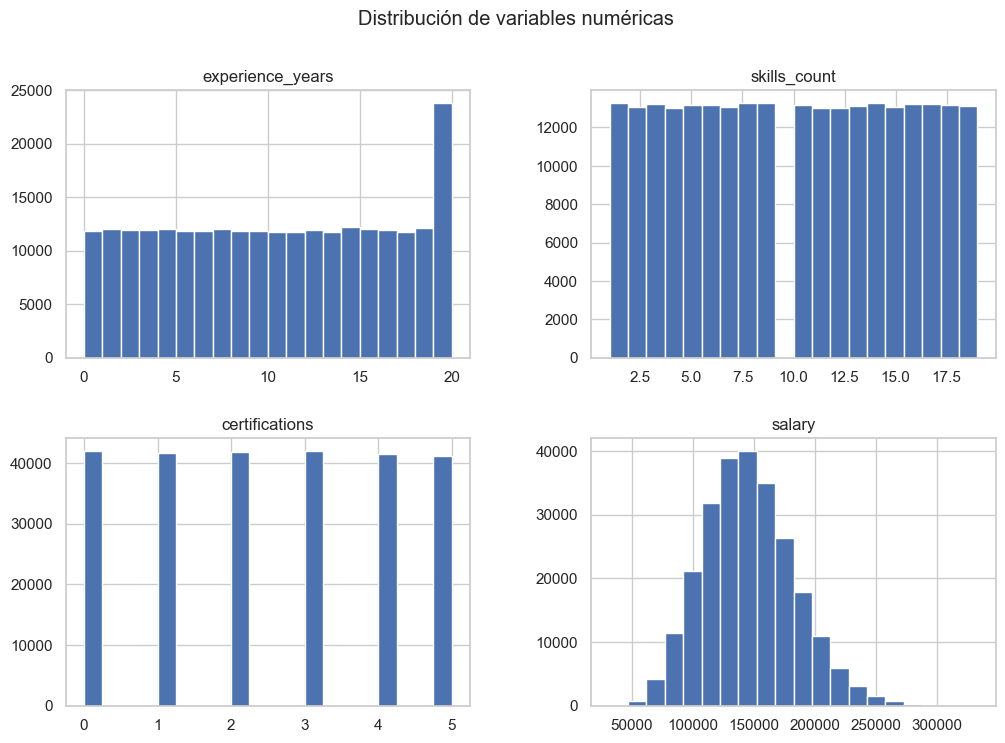

In [22]:
# =========================================
# 5. VISUALIZACIÓN INICIAL
# =========================================

# Histogramas para variables numéricas
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribución de variables numéricas")
plt.show()

In [23]:
# =========================================
# 6. LIMPIEZA DE DATOS
# =========================================
import warnings
warnings.filterwarnings('ignore')
# Eliminar duplicados
df = df.drop_duplicates()

# Manejo de valores nulos (ejemplo)
df = df.dropna()

# Verificar
df.isnull().sum()

# Estrategia:
# - Numéricas: imputar con media
# - Categóricas: imputar con moda

for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verificar que no queden nulos
print("Valores nulos después de limpieza:")
print(df.isnull().sum())

Valores nulos después de limpieza:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64


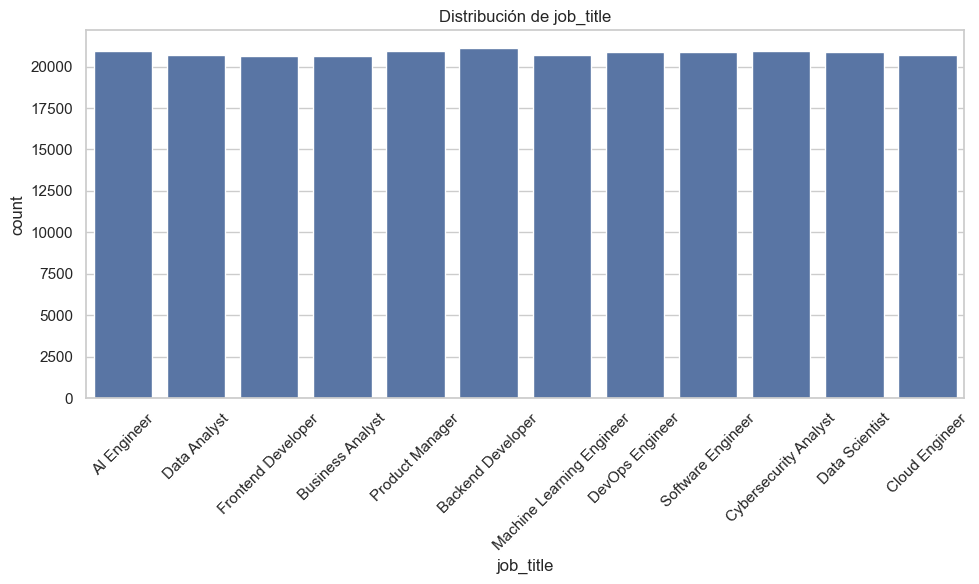

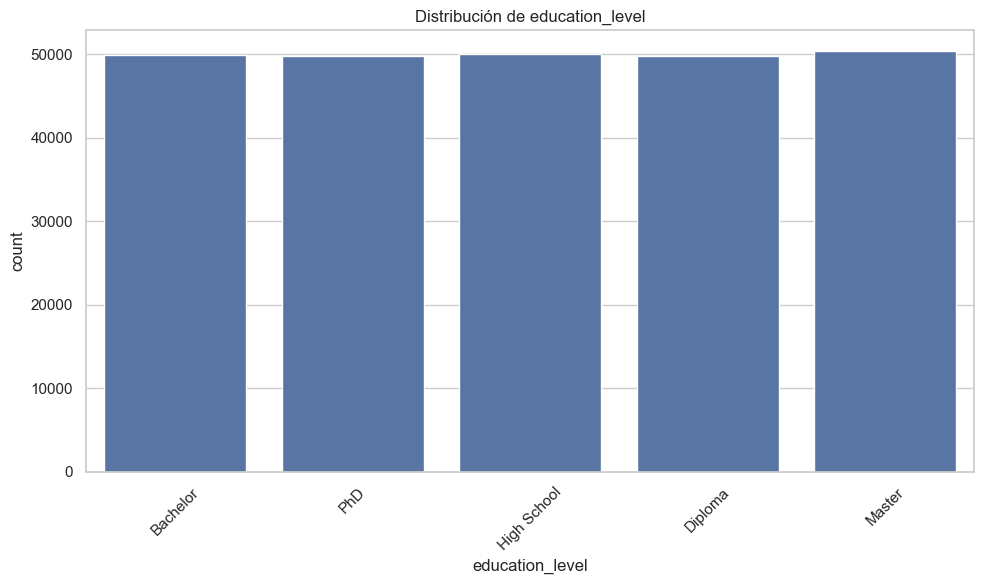

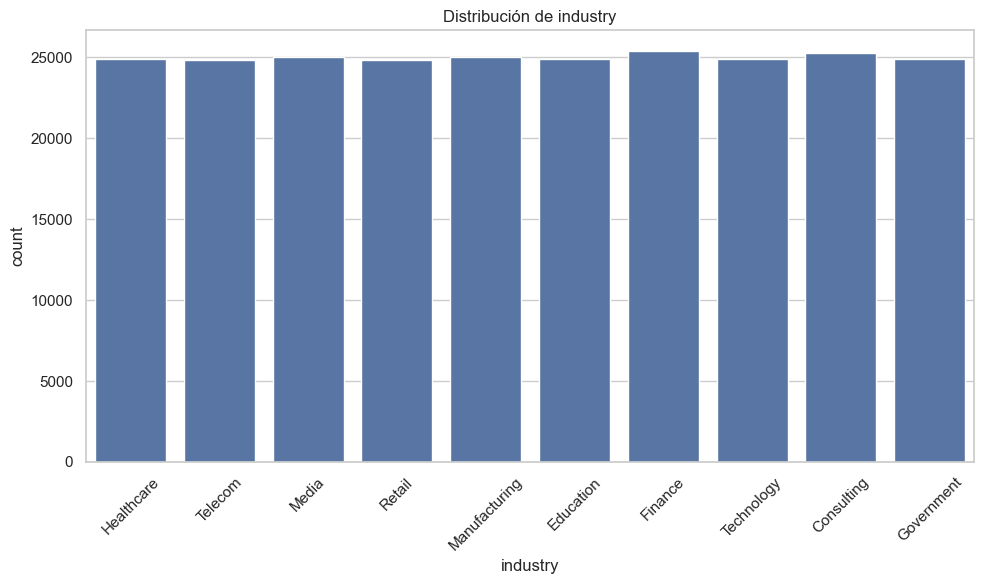

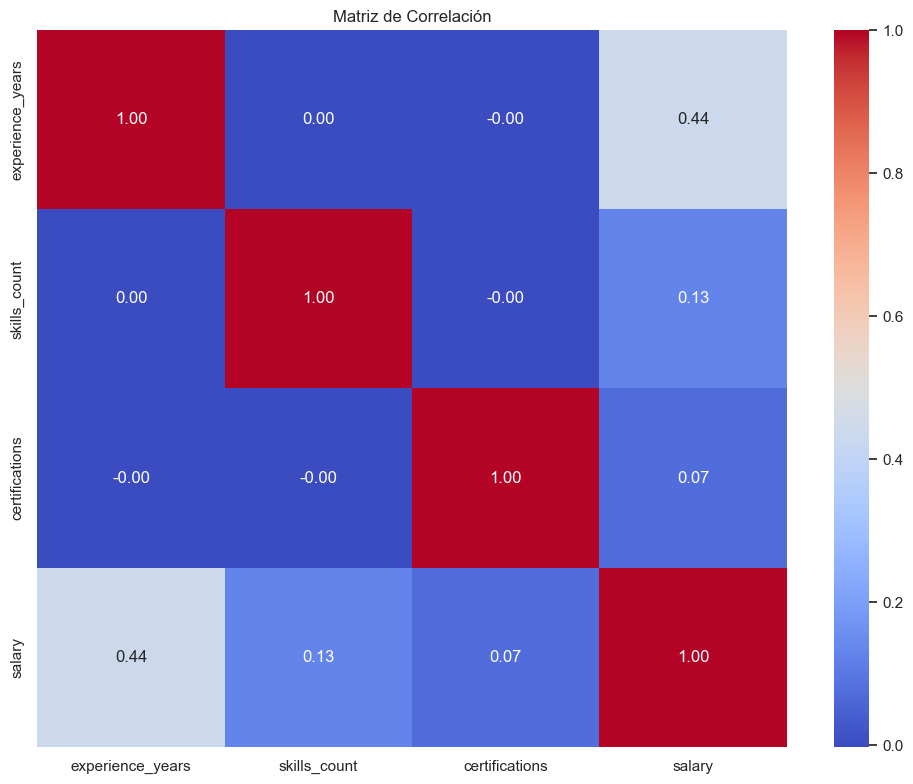

In [24]:
# =========================================
# 3. EXPLORACIÓN INICIAL (EDA) 2/2
# =========================================

# =========================================
# COUNTPLOTS - VARIABLES CATEGÓRICAS
# =========================================

# Seleccionar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Limitar a primeras 4-6 para no saturar
for col in cat_cols[:3]:
    plt.figure()
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# =========================================
# MATRIZ DE CORRELACIÓN (HEATMAP)
# =========================================

# Asegurarse de trabajar solo con variables numéricas
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

# Crear heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

In [25]:
# =========================================
# 7. GUARDAR DATASET PROCESADO
# =========================================

# Guardar para uso en modelado
df.to_csv('../dataset/cleaned/dataset_clean.csv', index=False)

print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.
